In [16]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from scipy.interpolate import RegularGridInterpolator
from plant.battery import battery_step, coef_quad, Uoc,thermal_model
from plant.powertrain import powertrain
import sys, os
sys.path.append(os.path.abspath('..'))

# Single-lap Dynamic Programming

Solves the fuel-optimal power split over a single qualifying lap via backward
DP on a 2D state grid (SoC, E_ES2K), full knowledge of the future velocity
profile assumed. Used as the offline benchmark / upper bound against which
the rule-based and ECMS controllers are compared in `Compare_Controllers.ipynb`.

**Inputs**: `data/qualifying_Canada/` velocity profile \
**Outputs**: `u_star`, single-lap SoC/power trajectory plots \
**Depends on**: `plant/battery.py`, `plant/powertrain.py`

## 1 Formulate optimization problem

**Objective**
$$
\min \quad J = \sum_{k=0}^{N-1} \dot{m}(k) \, \Delta t
\qquad \text{where} \qquad
\dot{m}(k) = \frac{P_{ICE}(k) + P_{ICE,0}}{\eta_{ICE} \, H_{lhv}}
$$

**State dynamics**
$$
\begin{aligned}
SoC(k+1) &= SoC(k) - \frac{\Delta t}{Q_{bat} \quad U_2(SoC(k))} \, P_{MGU\text{-}K}(k) \\[6pt]
E_{ES2K}(k+1) &= E_{ES2K}(k) + \max\big(P_{MGU\text{-}K}(k), \, 0\big) \, \Delta t
\end{aligned}
$$

**Power balance** (regime dependent, the ICE cannot absorb negative power; excess braking power is dissipated by the mechanical brakes, at no fuel or energy cost)
$$
P_{gb}(k) =
\begin{cases}
P_{ICE}(k) + P_{MGU\text{-}K}(k), & P_{gb}(k) \ge 0 \quad \text{(traction)}\\[4pt]
P_{MGU\text{-}K}(k) + P_{brake}(k), & P_{gb}(k) < 0 \quad \text{(braking)}
\end{cases}
$$

**Control bounds** single decision variable $P_{MGU\text{-}K}(k)$; $P_{ICE}(k)$ and $P_{brake}(k)$ follow from the power balance above.

$$
\begin{cases}
P_{gb}(k) - P_{ICE}^{max} \;\le\; P_{MGU\text{-}K}(k) \;\le\; P_{gb}(k), & P_{gb}(k) \ge 0\\[8pt]
P_{gb}(k) \;\le\; P_{MGU\text{-}K}(k) \;\le\; 0, & P_{gb}(k) < 0
\end{cases}
$$

together with, at every $k$:
$$
\begin{aligned}
P_{MGU\text{-}K}^{min} \;\le\;& P_{MGU\text{-}K}(k) \;\le\; P_{MGU\text{-}K}^{max} \\[6pt]
\frac{(SoC^{max} - SoC(k))\,Q_{bat} \quad U_2(SoC(k))}{-\Delta t} \;\le\;& P_{MGU\text{-}K}(k) \;\le\; \frac{(SoC^{min} - SoC(k))\,Q_{bat}\quad U_2(SoC(k))}{-\Delta t} \\[6pt]
P_{MGU\text{-}K}(k) \;\le\;& \frac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t}
\end{aligned}
$$

**Component and regulatory limits**
$$
\begin{aligned}
0 &\le P_{ICE}(k) \le P_{ICE}^{max} \\
P_{brake}(k) &\le 0 \\
0 &\le \dot{m}(k) \le \dot{m}^{max} = 75 \ \text{kg/h} \\
0 &\le E_{ES2K}(k) \le E_{ES2K}^{max} = 9 \ \text{MJ}
\end{aligned}
$$

### Set parameters and extract data

In [17]:
#Define the parameters
Delta_t = 0.1

# Fuel consumption in grams per unit energy
Voc = params['V_oc_nom'] 
Q_bat = params['E_pack_capacity'] / Voc

# Limits on Batt Power, Eng Power, SOC
P_MGU_max = params['P_MGU_max']  # 350[kW]
P_MGU_min = params['P_MGU_min']  # -200[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SOC_min = params['SoC_min']     # 0.1[-]
SOC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']

# Load Data: of t,v,a
data = np.load('data/qualifying_Canada/Canada_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('data/qualifying_Canada/power_domand_quali.npy')
P_gb = data_of_power_gb[1,:]

### Usefull plot of the available information 

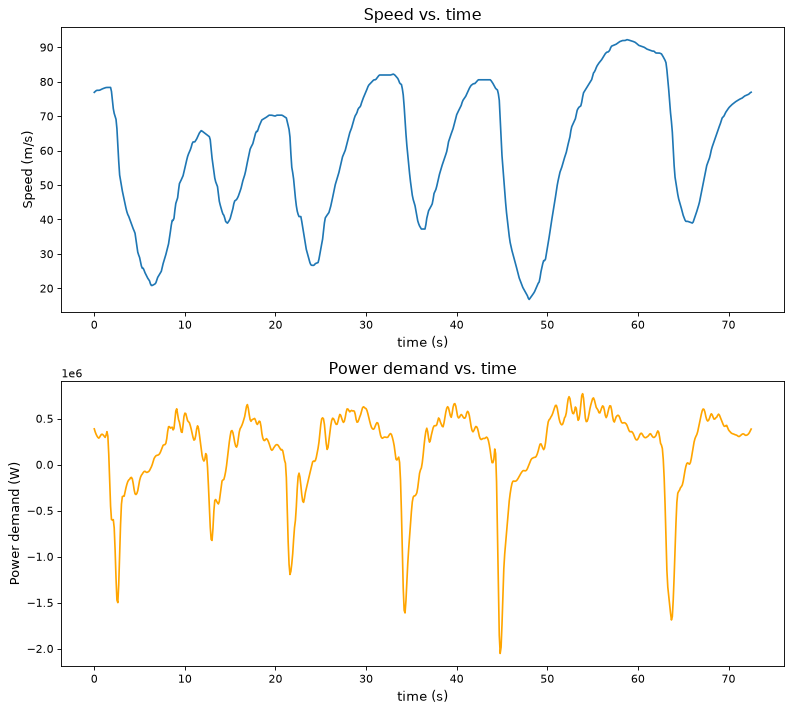

In [18]:
plot.figure(num=1, figsize=(10, 9), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(2,1,1)
plot.plot(t,v)
plot.ylabel('Speed (m/s)', fontsize= 12)
plot.xlabel('time (s)', fontsize= 12)
plot.title('Speed vs. time', fontsize=14)

plot.subplot(2,1,2)
plot.plot(t, P_gb,'orange')
plot.xlabel('time (s)', fontsize=12)
plot.ylabel('Power demand (W)', fontsize=12)
plot.title('Power demand vs. time', fontsize=14)
plot.tight_layout()
plot.show()

### Define grid for state space

In [19]:
SoC_grid = np.linspace(SOC_min,SOC_max, 50)
E_ES2K_grid = np.linspace(0, E_ES2K_max, 50)

#Grid size
ns = len(SoC_grid) # No. of states
ne = len(E_ES2K_grid)

# Planning horizon (time steps)
N = len(t)

# Preallocate Value Function (rows index state, columns index time)
V = np.inf*np.ones((ns,ne,N+1))


# Preallocate Control (rows index state, columns index time)
u_star = np.zeros((ns,ne, N))

## 2. Solve dynamic program
This is where the magic happens. Below I formulate the DP and determine the optimal control `u_star` for each state $x = (SOC,E_{ES2K})$. A key part of this is the 2D interpolation function that allows me to manage the continuous nature of the state space. so the propagated states `SoC_nxt` and `E_ES2K_next` will almost never fall exactly on a grid point. Therefore, we perform a 2D interpolation between grid points to evaluate `V_nxt`.

In [20]:
# Boundary Condition of Value Function (Principle of Optimality)
V[:,:,N] = 0

# Iterate backward in time
for k in range(N-1,-1,-1):

    interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
    # Iterate over SOC
    for i in range(0,ns):
        #Iterate over E_ES2K
        for j in range(0,ne):
            # Find dominant bounds for P_batt
            if P_gb[k]>=0:
                lb = max([(((SOC_max - SoC_grid[i]) * Q_bat * Uoc(SoC_grid[i], coef_quad)) / -Delta_t), P_MGU_min,P_gb[k] - P_eng_max])
                ub = min([(((SOC_min - SoC_grid[i]) * Q_bat * Uoc(SoC_grid[i], coef_quad)) / -Delta_t), P_MGU_max, P_gb[k], (E_ES2K_max-E_ES2K_grid[j])/Delta_t]) 
            else: 
                lb = max([(((SOC_max - SoC_grid[i]) * Q_bat * Uoc(SoC_grid[i], coef_quad)) / -Delta_t), P_MGU_min, P_gb[k]])
                ub = min([(((SOC_min - SoC_grid[i]) * Q_bat * Uoc(SoC_grid[i], coef_quad)) / -Delta_t), 0]) 

            # Grid Battery Power between dominant bounds
            P_mguk_grid = np.linspace(lb, ub, 200)

            # Compute engine power (vectorized for all P_batt_grid)
            if P_gb[k]>=0:
                P_eng_req = P_gb[k] - P_mguk_grid
                P_eng = np.clip(P_eng_req, 0, P_eng_max)
                shortfall = np.maximum(P_gb[k] - (P_eng + P_mguk_grid), 0)
            else:
                P_eng = np.zeros_like(P_mguk_grid)
                shortfall = np.zeros_like(P_mguk_grid)
            m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
            m_dot = np.clip(m_dot, 0, params['m_dot_max']/3600)

            # Cost-per-time-step, a.k.a. fuel consumed at each stage (vectorized for all P_batt_grid)
            g_k = m_dot * Delta_t

            # compute next SOC and E_ES2K using dynamics
            SoC_nxt = SoC_grid[i] - P_mguk_grid*Delta_t/(Q_bat * Uoc(SoC_grid[i], coef_quad))
            E_ES2K_next = E_ES2K_grid[j] + np.maximum(P_mguk_grid, 0)*Delta_t

            # Compute value function at nxt time step (need to interpolate)
            points = np.column_stack([SoC_nxt, E_ES2K_next])
            V_nxt = interp_Vnext(points)


            # Embed the penalty directly into the cost array BEFORE minimization
            total_cost = (g_k + V_nxt).astype(float)
            total_cost[shortfall > 0] = np.inf
            
            # Value Function (Principle of Optimality)
            ind = np.argmin(total_cost)
            V[i,j,k] = total_cost[ind]

            # Save Optimal Control
            u_star[i,j,k] = P_mguk_grid[ind]


### On the power shortfall penalty

A qualifying lap has essentially zero tolerance for power shortfall: any
instant where delivered power falls short of requested power costs lap
time directly, and a benchmark meant to establish the fuel-optimal
*feasible* strategy is not useful if the strategy itself is infeasible.

The shortfall is folded back into the DP cost as a heavy penalty:

```python
total_cost[shortfall > 0] = np.inf
```

This is a deliberate but imperfect choice, and worth being explicit about.
A weighted penalty is not a hard guarantee: in principle a large enough
fuel saving could still make the optimizer accept a tiny shortfall, since
it competes on the same additive cost rather than being excluded outright.
In practice, with this weight, no shortfall survives in the resulting
trajectory (see the requested vs. delivered power plot below). A cleaner
implementation would mask out any action with shortfall > 0 directly
(cost = +inf, or removed from the feasible action set before the argmin)
rather than relying on a weight tuned to dominate the fuel term by several
orders of magnitude. That refinement is left as a follow-up; the intent
behind `1e3` here is "this is not negotiable," not "this is expensive."

## 3. Simulate optimal energy management results

Now that I've solved the DP over the full race, I can use the `u_star` map to
simulate the optimal strategy lap by lap, starting from a fully charged battery
(SoC_0 = 0.9).

In [21]:
def optimize_PHEV(SOC_0,E_ES2K_0):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    P_MGUK_sim = np.zeros(N)
    P_eng_sim = np.zeros(N)
    J_sim = np.zeros(N)
    m_dot_sim = np.zeros(N)
    shortfall = np.zeros(N)
    E_recharge_sim = np.zeros(N)
    P_mech_MGU_K_real= np.zeros(N)
    Tbat_sim = np.zeros(N)
    
    # Initialize
    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_recharge_sim[0] = 0
    Tbat_sim[0]=params['T_bat_init']

    # Simulate PHEV Dynamics
    for k in range(0,(N-1)):
        
        interp_u = RegularGridInterpolator((SoC_grid, E_ES2K_grid), u_star[:,:,k], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[k], E_ES2K_sim[k]]])
        P_MGUK_sim[k] = interp_u(point)[0]

        P_eng_sim[k], P_elect_MGU_K, P_mech_MGU_K_real[k], shortfall_L, E_ES2K_sim[k+1], E_recharge_sim[k+1],m_dot_sim[k] = powertrain(P_gb[k], P_MGUK_sim[k], E_ES2K_sim[k], E_recharge_sim[k], params, Delta_t,control_mode='P2')
        SoC_sim[k+1], _, I2_k = battery_step(SoC_sim[k], P_elect_MGU_K, coef_quad, Tbat_sim[k],params,Delta_t)
        
        Tbat_sim[k+1] = thermal_model(I2_k, Tbat_sim[k], params, Delta_t)

        J_sim[k] = m_dot_sim[k]*Delta_t
        if P_gb[k]>0:
    
            shortfall[k] = shortfall_L
        else:
            shortfall[k] = 0
        
    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim, shortfall

P_MGUK_sim90, P_eng_sim90, m_dot_sim90, J_sim90, SOC_sim90, E_ES2K_sim90, shortfall90 = optimize_PHEV(SOC_0=0.90,E_ES2K_0=0.0)

fuel_dp = np.sum(J_sim90) * 1e3  # g
print(f"fuel: {fuel_dp:.2f} g | final SoC: {SOC_sim90[-2]:.4f} | deploy: {E_ES2K_sim90[-2]/1e6:.3f} MJ")


fuel: 563.05 g | final SoC: 0.5130 | deploy: 9.000 MJ


By simulating the powertrain dynamics over this qualifying lap without imposing any soft or hard constraints on the final state, the optimal energy management strategy yielded the following results:

    Fuel consumed: 563.05 g
    Final SoC: 0.5130
    Energy Deployed: 9.000 MJ
    
As expected, without a terminal penalty or constraint on the battery, the algorithm freely deploys the available electrical energy to minimize fuel consumption.

## 4. Analysis of the Optimal Energy Management Strategy
The simulation results provide a detailed insight into how the Dynamic Programming algorithm manages the energy flows throughout the qualifying lap. The five subplots illustrate the optimal state trajectories and the control policy in action:

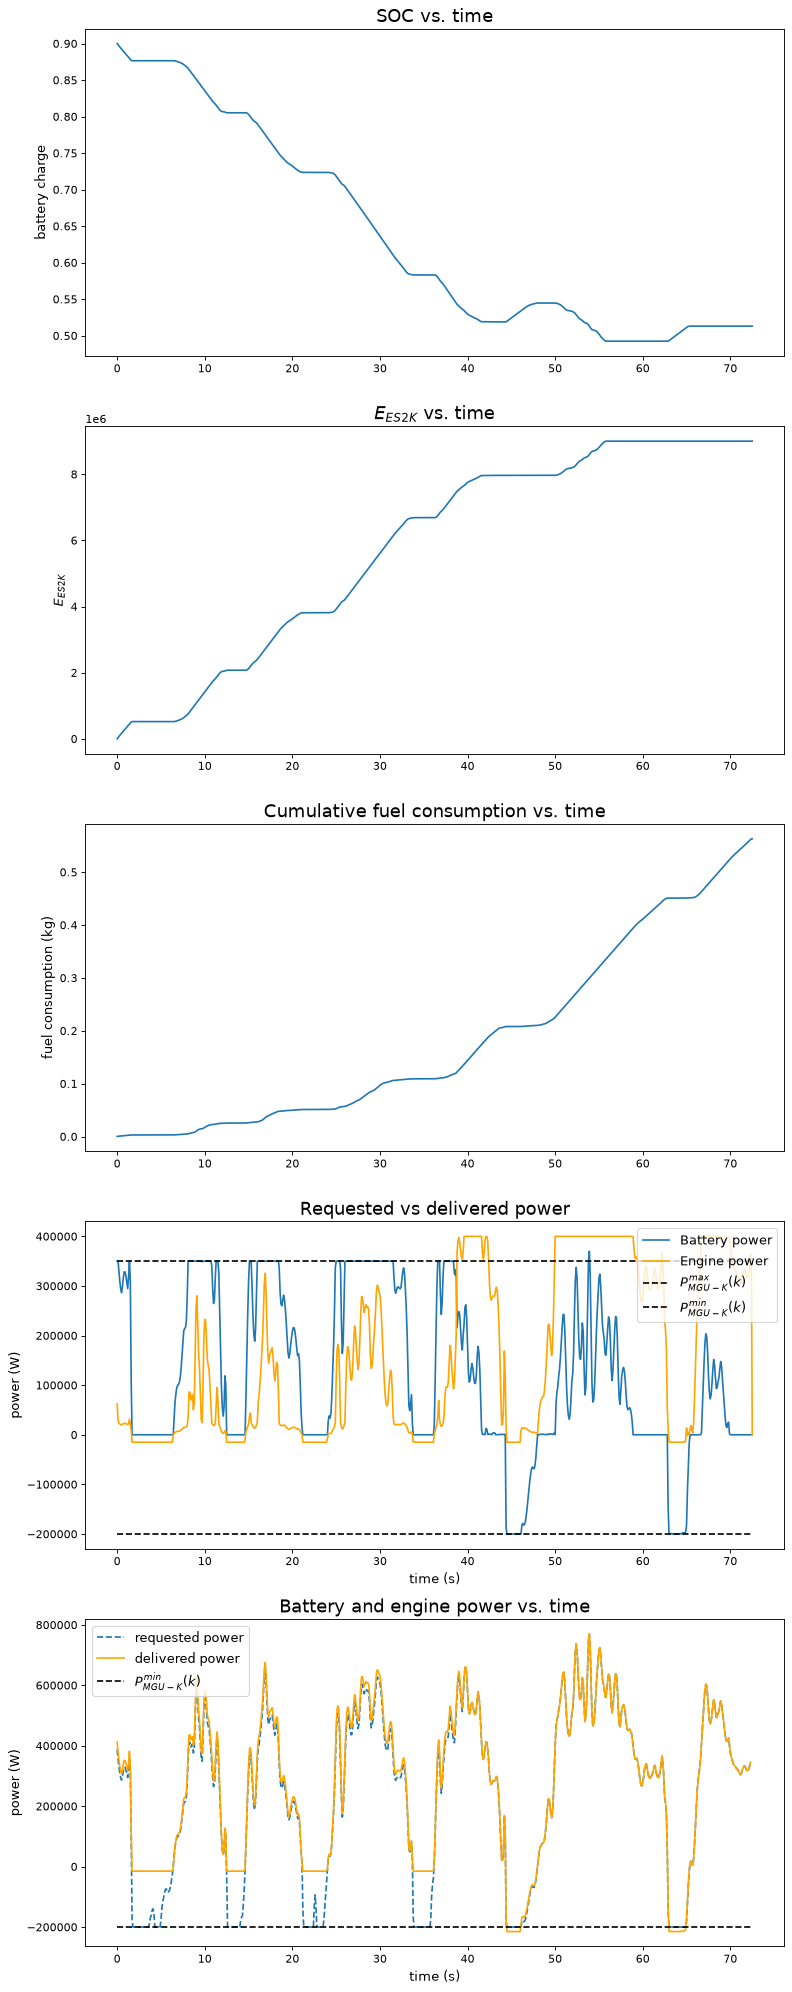

In [22]:
## Plot Simulation Results
plot.figure(num=5, figsize=(10, 25), dpi=80, facecolor='w', edgecolor='k')




plot.subplot(5,1,1)
plot.plot(t, SOC_sim90)
plot.ylabel('battery charge', fontsize=12)
plot.title('SOC vs. time', fontsize=16)

plot.subplot(5,1,2)
plot.plot(t, E_ES2K_sim90)
plot.ylabel('$E_{ES2K}$', fontsize=12)
plot.title('$E_{ES2K}$ vs. time', fontsize=16)

plot.subplot(5,1,3)
plot.plot(t, np.cumsum(J_sim90))
plot.ylabel('fuel consumption (kg)', fontsize=12)
plot.title('Cumulative fuel consumption vs. time', fontsize=16)


plot.subplot(5,1,4)
plot.plot(t, P_MGUK_sim90, label='Battery power')
plot.plot(t, P_eng_sim90, 'orange', label='Engine power')
plot.plot(t, P_MGU_max*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}(k)$')
plot.plot(t, P_MGU_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plot.ylabel('power (W)', fontsize=12)
plot.title('Requested vs delivered power', fontsize=16)
plot.xlabel('time (s)', fontsize=12)
plot.legend(loc=1, fontsize=12)

P_gb2 = np.zeros_like(P_gb)
for k in range(len(P_gb)):
    if P_gb[k]<=P_MGU_min:
        P_gb2[k] = P_MGU_min
    else:
        P_gb2[k]=P_gb[k]

plot.subplot(5,1,5)
plot.plot(t[0:-2], P_gb2[0:-2], '--',label='requested power')
plot.plot(t[0:-2], P_eng_sim90[0:-2]+P_MGUK_sim90[0:-2], 'orange', label='delivered power')
plot.plot(t, P_MGU_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plot.ylabel('power (W)', fontsize=12)
plot.title('Battery and engine power vs. time', fontsize=16)
plot.xlabel('time (s)', fontsize=12)
plot.tight_layout()
plot.legend(loc=0, fontsize=12)

### Reading the results

* **SoC vs. time**  the state of charge starting an initial value of 0.90, depletes over the lap while exhibiting distinct recovery phases during braking events. This overall discharge trend is expected for a single-lap, fuel-minimal benchmark; without the requirement to preserve a reserve for subsequent laps, the dynamic programming algorithm has no incentive to leave electrical energy unused.


* **E_ES2K vs. time**: this plot tracks the cumulative MGU-K deployed energy against the regulatory per-lap budget. As clearly shown in the graph, the 9 MJ maximum allowance is fully exploited, with the budget saturating by roughly t=55 s. After this point, the MGU-K can no longer provide tractive energy for the remainder of the lap, forcing the vehicle to rely solely on the ICE.

* **Cumulative fuel consumption** This curve represents the primary cost function of the optimization. The total fuel mass reaches **0.521 kg** over the lap.

* **Requested vs. delivered power (engine/battery split):** This plot visualizes how the DP optimally splits the requested gearbox power between the ICE and the MGU-K. The battery power strictly respects its physical constraints but frequently saturates at both its upper ($P_{MGU-K}^{max}$) and lower ($P_{MGU-K}^{min}$) bounds. This aggressive strategy confirms that the optimizer exploits the electric motor to its absolute limits whenever possible to minimize overall fuel consumption.

* **Battery and engine power vs. time:** This panel serves as the direct verification of the shortfall penalty implemented in the optimization formulation. The delivered power (solid orange) perfectly tracks the requested power (dashed blue) during all traction phases, with no visible gaps. This confirms that the infinite cost penalty applied to the shortfall achieves its intended effect over the entire lap, guaranteeing full drivability. The only deviations naturally occur during heavy braking, where the negative power demand exceeds the $P_{MGU-K}^{min}$ regenerative limit, and the mechanical brakes seamlessly intervene to dissipate the remaining energy.